In [3]:
import pandas as pd
import warnings
import numpy as np
warnings.filterwarnings("ignore")

## Estrazione dati da MongoDB

In [4]:
from pymongo import MongoClient
from dotenv import load_dotenv
import os

In [149]:
load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")

client = MongoClient(MONGO_URI)
db=client["PolymerPrediction"]
collection=db["biceranoPolymers"]
target="glass_cte"
#print(collection.count_documents({}))

In [150]:
docs = list(collection.find({}))
df = pd.DataFrame(docs)

# espando il dizionario "properties"
prop_df = pd.json_normalize(df["properties"])

# integro nel dataframe
df = pd.concat([df.drop(columns=["properties"]), prop_df], axis=1)

# rimuovo righe senza SMILES, Tg o densità o con SMILES malformato
df = df.dropna(subset=["smiles", target])
df = df[~df["smiles"].str.contains(r"\[\[", na=False)].copy()
df.describe()

,Tg,density,glass_cte,rubber_cte
count,223.000000,63.000000,223.000000,223.000000
mean,419.421525,1.188603,240.505115,767.424144
std,95.524073,0.195558,90.439190,195.287393
min,300.000000,0.838000,104.314790,268.200810
25%,349.500000,1.048000,172.887802,664.410143
50%,390.000000,1.184000,221.040558,764.977014
75%,473.000000,1.260000,293.769836,890.594731
max,685.000000,1.953000,484.398992,1271.147579


## Integrazione descrittori RDKit

In [151]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
import numpy as np

descriptor_names = [desc[0] for desc in Descriptors._descList]
calc = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)
# print(descriptor_names)

def rdkit_descr(smi):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return {d: np.nan for d in descriptor_names}
    values = calc.CalcDescriptors(mol)
    return dict(zip(descriptor_names, values))

desc_df = df["smiles"].apply(rdkit_descr).apply(pd.Series)
desc_df.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
7,2.351667,2.351667,0.704722,0.704722,0.492023,19.833333,84.162,72.066,84.093900,36.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,9.619722,9.619722,0.280833,0.280833,0.438566,18.400000,72.063,68.031,72.021129,28.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,5.650807,5.650807,0.485248,0.485248,0.603310,14.538462,176.259,160.131,176.120115,70.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10,10.688309,10.688309,0.006783,0.006783,0.518339,12.400000,141.214,126.094,141.115364,58.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
11,2.393009,2.393009,0.548037,0.548037,0.557487,12.555556,118.179,108.099,118.078250,46.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [123]:
import seaborn as sns
import matplotlib.pyplot as plt


corr = desc_df.corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice di correlazione tra i descrittori")
plt.tight_layout()
plt.show()

TypeError: Series.corr() missing 1 required positional argument: 'other'

## Aggiunta Fingerprint

In [152]:
from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def morgan_fp(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return [0]*1024
    fp = morgan_gen.GetFingerprint(mol)  
    return list(fp)

fp_df = df["smiles"].apply(morgan_fp).apply(pd.Series)
fp_df.columns = [f"fp_{i}" for i in range(fp_df.shape[1])]

In [153]:
from rdkit.Chem import MACCSkeys

def maccs_fp(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return [0]*167  # MACCS ha 167 bit (indice 0 inutilizzato)
    fp = MACCSkeys.GenMACCSKeys(mol)
    return list(fp)
maccs_df = df["smiles"].apply(maccs_fp).apply(pd.Series)
maccs_df.columns=[f"maccs_{i}" for i in range(167)]

feature_df = pd.concat([desc_df, fp_df, maccs_df], axis=1)

## Pulizia dei dati

In [154]:
feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
feature_df = feature_df.fillna(feature_df.median(numeric_only=True))
feature_df = feature_df.dropna(axis=1, how="all")

# rimuovo colonne costanti (con varianza 0) 
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold=0.0)
sel.fit(feature_df)

mask = sel.get_support()
feature_df = feature_df.loc[:, mask]

print("Shape:", feature_df.shape[1])

Shape: 879


## Preparazione dataset (separazione target)

In [155]:
y = df[target]
X = feature_df.copy()
X.index = df.index
print("Shape X:", X.shape)
print("Shape y:", y.shape)
X.sample(10)

import numpy as np

X_np = np.ascontiguousarray(X.to_numpy(), dtype=np.float32)

print("dtype:", X_np.dtype)
print("contiguous:", X_np.flags['C_CONTIGUOUS'])
print("finite:", np.isfinite(X_np).all())
print("max abs:", np.max(np.abs(X_np)))


Shape X: (223, 879)
Shape y: (223,)
dtype: float32
contiguous: True
finite: True
max abs: 92832150000000.0


## Gradient Boosting
Anche se le colonne sono ancora tante, per farsi un'idea

In [156]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

random_state=26

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=random_state)

model_base = GradientBoostingRegressor(random_state=random_state)
model_base.fit(X_train, y_train)

pred_base = model_base.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred_base))
print("R2:", r2_score(y_test, pred_base))


MAE: 30.49065419426217
R2: 0.8207725317459944


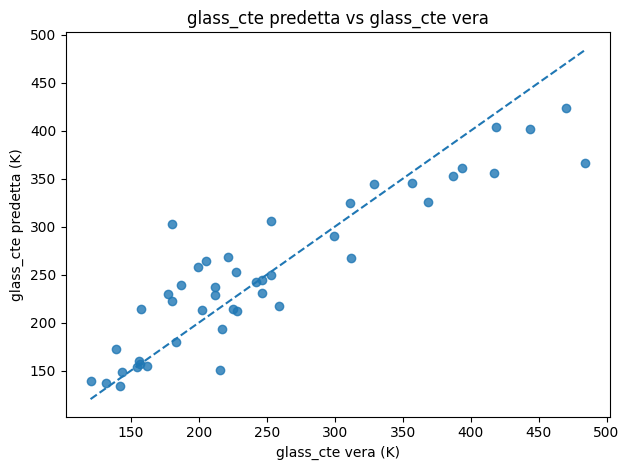

In [157]:
from matplotlib import pyplot as plt

plt.figure()
plt.scatter(y_test, pred_base, alpha=0.8)


# diagonale ideale
min_val = min(y_test.min(), pred_base.min())
max_val = max(y_test.max(), pred_base.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel(f"{target} vera (K)")
plt.ylabel(f"{target} predetta (K)")
plt.title(f"{target} predetta vs {target} vera")

plt.tight_layout()
plt.show()

## Cross validation

Per la validazione incrociata uso 5-fold CV, poiché rappresenta il miglior compromesso tra stabilità della stima e quantità di dati utilizzata per l’addestramento. Con dataset piccoli e un numero elevato di feature (come in questo caso), un numero maggiore di fold aumenterebbe la varianza delle performance e renderebbe il modello più instabile. 

In [158]:
from sklearn.model_selection import GridSearchCV, KFold

param_grid = {
    "n_estimators": [200, 400, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

gb_model = GradientBoostingRegressor(random_state=random_state)

# Cross-validation 5 fold
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)

# Grid search
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Risultati tuning
print("Best parameters found:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(-grid_search.best_score_)

# Valutazione finale su test set
best_model = grid_search.best_estimator_
pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("\nPerformance on Test Set:")
print(f"MAE: {mae}")
print(f"R² : {r2}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters found:
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 800, 'subsample': 0.8}

Best CV MAE:
36.51804918884909

Performance on Test Set:
MAE: 30.16654480262461
R² : 0.8381197325598512


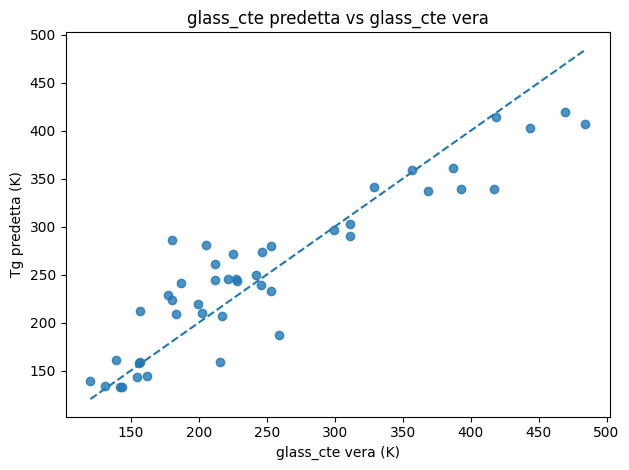

In [159]:

plt.figure()
plt.scatter(y_test, pred, alpha=0.8)


# diagonale ideale
min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel(f"{target} vera (K)")
plt.ylabel(f"Tg predetta (K)")
plt.title(f"{target} predetta vs {target} vera")

plt.tight_layout()
plt.show()

## Feature selection

### Mutual Info Regression

In [160]:
from sklearn.feature_selection import mutual_info_regression

# MI solo sul train
mi_scores = mutual_info_regression(X_train, y_train, random_state=random_state)

mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

# seleziono top N
N = 300
top_features_mi = mi_series.head(N).index

# applico selezione a train e test
X_train_mi = X_train[top_features_mi]
X_test_mi = X_test[top_features_mi]

print("Shape train dopo MI:", X_train_mi.shape)
print("Shape test dopo MI:", X_test_mi.shape)
print("Feature scelte (MI):", len(top_features_mi))

Shape train dopo MI: (178, 300)
Shape test dopo MI: (45, 300)
Feature scelte (MI): 300


In [161]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model_mi = GradientBoostingRegressor(random_state=random_state)
model_mi.fit(X_train_mi, y_train)

pred_mi = model_mi.predict(X_test_mi)

print("MAE:", mean_absolute_error(y_test, pred_mi))
print("R²:", r2_score(y_test, pred_mi))


MAE: 33.71854187143821
R²: 0.7670905792111571


### Permutation importance
Uso il modello del passaggio precedente perché serve un modello già addestrato e abbastanza buono

In [162]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(model_mi, X_train_mi, y_train, n_repeats=20, random_state=random_state)
perm_series = pd.Series(perm.importances_mean, index=X_train_mi.columns)
perm_series = perm_series.sort_values(ascending=False)

# selezione feature
thr = perm_series.mean()
selected = perm_series[perm_series > thr].index

X_train_perm = X_train_mi[selected]
X_test_perm = X_test_mi[selected]

print("Feature scelte (Permutation Importance):", X_train_perm.shape[1])


Feature scelte (Permutation Importance): 37


In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

test=pd.concat([X_train.reset_index().drop(columns=["_id"]), pd.DataFrame(y)], axis=0)
corr = test.corr(method="spearman")
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice di correlazione tra le feature")
plt.tight_layout()
plt.show()

KeyError: "['_id'] not found in axis"

In [163]:

model_perm = GradientBoostingRegressor(random_state=random_state)
model_perm.fit(X_train_perm, y_train)

pred_perm = model_perm.predict(X_test_perm)

print("MAE:", mean_absolute_error(y_test, pred_perm))
print("R²:", r2_score(y_test, pred_perm))


MAE: 33.32938691829361
R²: 0.7935423219576241


## Cross validation finale

In [164]:
from sklearn.model_selection import GridSearchCV, KFold

param_grid = {
    "n_estimators": [200, 400, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

gb = GradientBoostingRegressor(random_state=random_state)

# Cross-validation 5 fold
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)

# Grid search
grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_perm, y_train)

# Risultati tuning
print("Best parameters found:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(-grid_search.best_score_)

# Valutazione finale su test set
best_model = grid_search.best_estimator_
pred = best_model.predict(X_test_perm)

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("\nPerformance on Test Set:")
print(f"MAE: {mae}")
print(f"R² : {r2}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters found:
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 800, 'subsample': 0.8}

Best CV MAE:
34.1475073327161

Performance on Test Set:
MAE: 31.234430774990248
R² : 0.8084148601950557


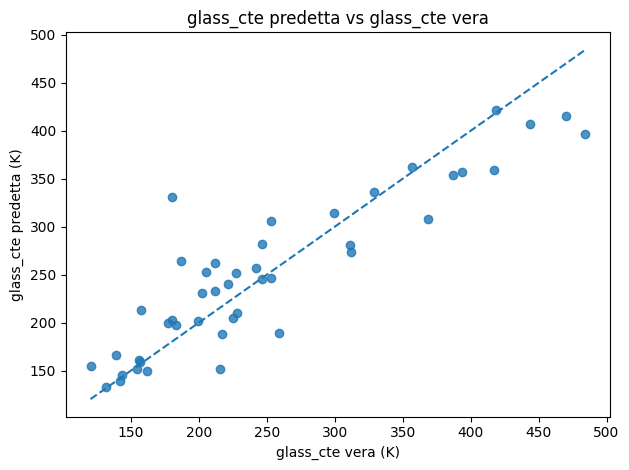

In [165]:

plt.figure()
plt.scatter(y_test, pred, alpha=0.8)


# diagonale ideale
min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel(f"{target} vera (K)")
plt.ylabel(f"{target} predetta (K)")
plt.title(f"{target} predetta vs {target} vera")

plt.tight_layout()
plt.show()

### UMAP

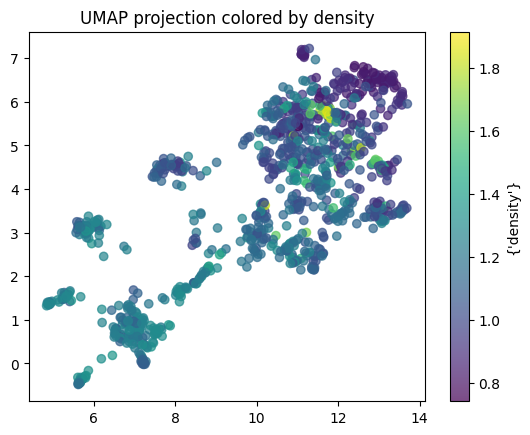

In [100]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

plt.scatter(X_umap[:,0], X_umap[:,1], c=y, alpha=0.7)
plt.colorbar(label={target})
plt.title(f"UMAP projection colored by {target}")
plt.show()

In [44]:
from sklearn.cluster import KMeans

labels = KMeans(n_clusters=2, random_state=42).fit_predict(X_umap)

In [45]:
df_umap = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])
df_umap["cluster"] = labels
df_umap[target] = y.values

df_umap.groupby("cluster")[target].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,140.0,287.435714,72.665609,130.0,222.5,289.5,333.5,600.0
1,164.0,422.993902,107.020123,171.0,361.5,411.0,493.0,685.0


In [46]:
X_clustered = X.copy()
X_clustered["cluster"] = labels

cluster_means = X_clustered.groupby("cluster").mean()
(cluster_means.loc[1] - cluster_means.loc[0]).abs().sort_values(ascending=False).head(10)

Ipc                    1.175782e+12
BertzCT                6.658524e+02
HeavyAtomMolWt         1.399329e+02
MolWt                  1.391805e+02
ExactMolWt             1.389888e+02
SMR_VSA7               5.918089e+01
LabuteASA              5.766096e+01
PEOE_VSA14             5.599807e+01
SlogP_VSA6             4.880595e+01
NumValenceElectrons    4.542021e+01
dtype: float64

In [47]:
from sklearn.preprocessing import StandardScaler

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X),
    columns=X.columns,
    index=X.index
)
X_clustered = X_scaled.copy()
X_clustered["cluster"] = labels

cluster_means = X_clustered.groupby("cluster").mean()
(cluster_means.loc[1] - cluster_means.loc[0]).abs().sort_values(ascending=False).head(10)

fp_356          1.461452
FractionCSP3    1.416563
fp_849          1.397058
maccs_162       1.397058
maccs_165       1.342273
maccs_163       1.328085
fp_726          1.285394
maccs_128       1.206888
SMR_VSA7        1.136021
fr_benzene      1.083097
dtype: float64

### Univariate regression - Analisi dei descrittori (solo per esplorazione)

In [70]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

scores = []

for col in X.columns:
    X_col = X[[col]]  
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_col, y, test_size=0.2, random_state=random_state
    )
    
    model = RandomForestRegressor(n_estimators=200, random_state=random_state)
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    
    scores.append({
        "feature": col,
        "MAE": mae,
        "R2": r2
    })

import pandas as pd
results = pd.DataFrame(scores)
results_sorted = results.sort_values("MAE")
results_sorted.head(20)

,feature,MAE,R2
29,HallKierAlpha,45.488663,0.717673
107,RingCount,46.231384,0.716148
60,SlogP_VSA6,47.633040,0.680697
30,Ipc,48.079946,0.652734
94,NumAromaticRings,48.509268,0.697374
84,FractionCSP3,51.161956,0.601014
56,SlogP_VSA2,51.342939,0.678836
50,SMR_VSA7,51.987965,0.653236
126,fr_benzene,52.865304,0.652786
92,NumAromaticCarbocycles,52.865304,0.652786


In [71]:
results.sort_values("R2", ascending=False).head(20)

,feature,MAE,R2
29,HallKierAlpha,45.488663,0.717673
107,RingCount,46.231384,0.716148
94,NumAromaticRings,48.509268,0.697374
60,SlogP_VSA6,47.633040,0.680697
56,SlogP_VSA2,51.342939,0.678836
50,SMR_VSA7,51.987965,0.653236
92,NumAromaticCarbocycles,52.865304,0.652786
126,fr_benzene,52.865304,0.652786
30,Ipc,48.079946,0.652734
16,BertzCT,53.946039,0.623101


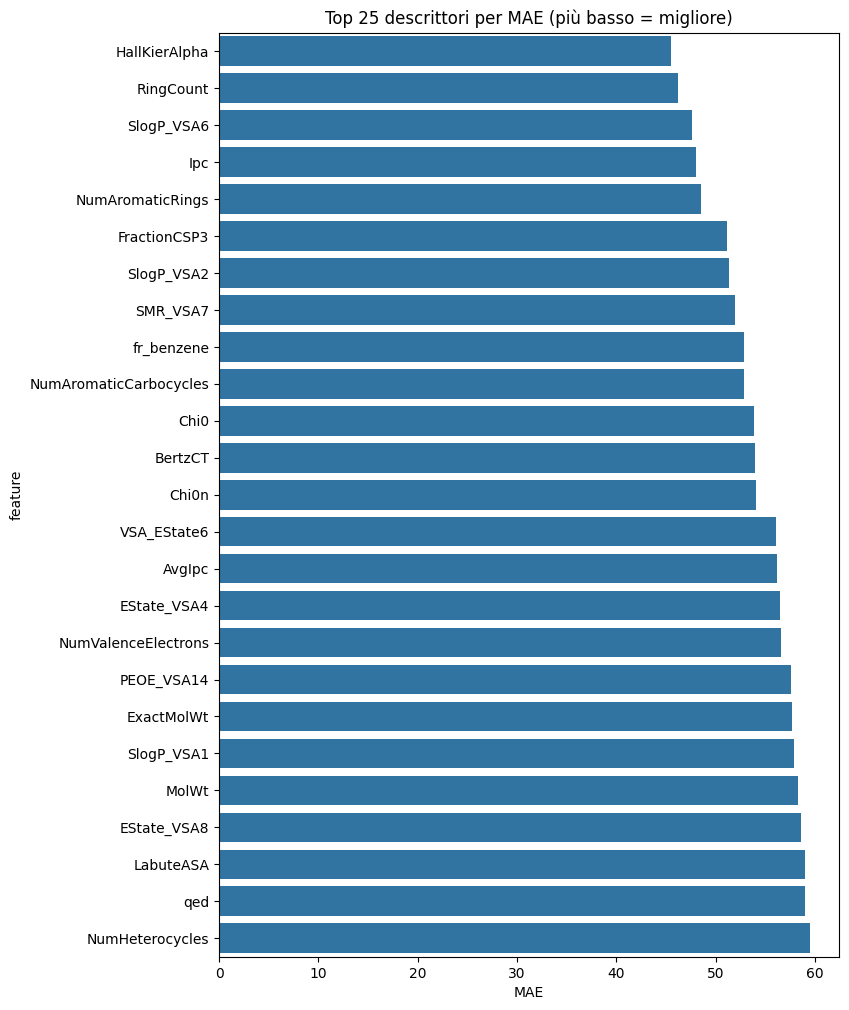

In [72]:

plt.figure(figsize=(8,12))
sns.barplot(data=results_sorted.head(25), x="MAE", y="feature")
plt.title("Top 25 descrittori per MAE (più basso = migliore)")
plt.show()
